# Titanic Study

### Study on Titanic dataset using various methods and functions and graphs to evalutate the correlation between various factors and how they affect and are related to survivability of a passenger 

### Importing Libraries


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("seaborn-v0_8")

##### Date Cleaning and filling Null Values in Age and Embark town columns as it contained lesser number of null values and dropping column Deck as almost 77% of columns contained null values

In [ ]:
df=sns.load_dataset("titanic")
df['age']=df['age'].fillna(
    df.groupby(by=['pclass'])['age'].transform("median")
)
df.drop(columns=['deck'],inplace=True)
df['embark_town'] = df['embark_town'].fillna(
    df.groupby(by=['pclass'])['embark_town'].transform(lambda x:x.mode()[0]))

df.info()

In [36]:
df.describe(include='object')

,sex,embarked,who,embark_town,alive
count,891,889,891,891,891
unique,2,3,3,3,2
top,male,S,man,Southampton,no
freq,577,644,537,646,549


### Univariate Analysis

#### Age Distribution

<Axes: xlabel='age', ylabel='Count'>

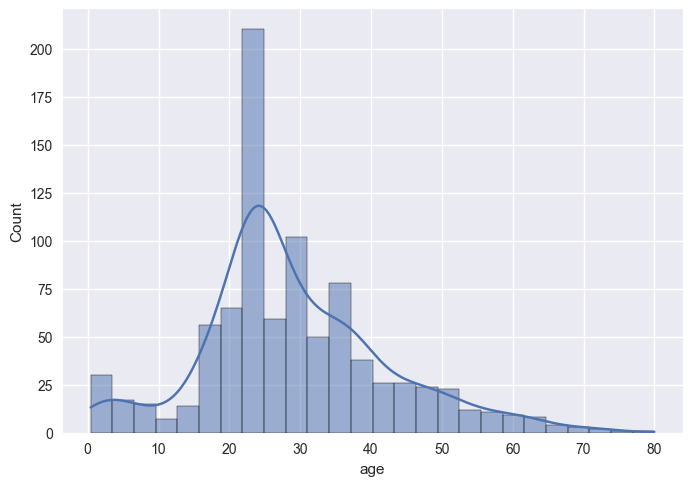

In [38]:
sns.histplot(data=df,x="age",kde=True)

##### Observation - 
##### 1. Most of the passengers belong to the age group from 20 to 30 range 
##### 2. The passengers age varies to a range of 80 

#### Sex Distribution

<Axes: xlabel='sex', ylabel='count'>

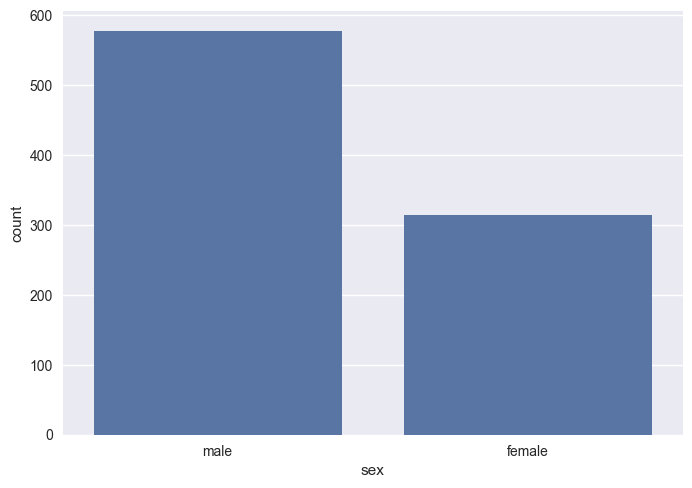

In [58]:
sns.countplot(
    data=df,
    x="sex",
    # hue="survived"
)

##### Observation - 
##### 1. Most of the passengers on the Ship were Males 

#### Fare Distribution

<Axes: xlabel='fare', ylabel='Count'>

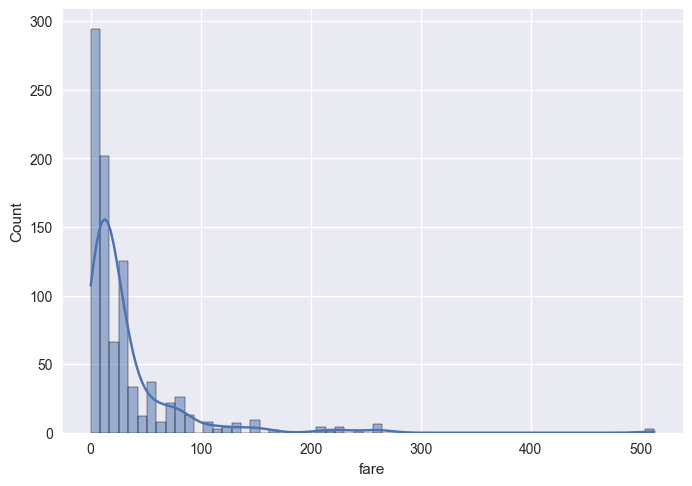

In [60]:
sns.histplot(data=df,x="fare",kde=True)

##### Observation - 
##### 1. The fare for the Ship ranges from 10$ to 500$ 
##### 2. Most of the passengers paid lesser amount of money for the Titanic

#### Passenger Class Distribution

<Axes: xlabel='pclass', ylabel='count'>

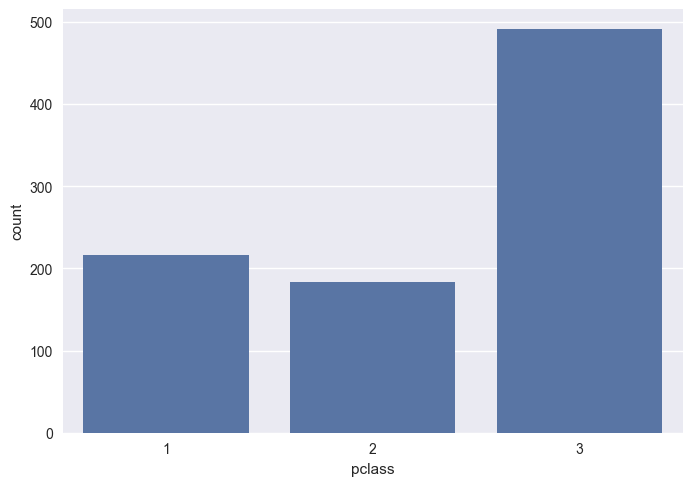

In [61]:
sns.countplot(
    data=df,
    x="pclass")

##### Observation - 
##### 1. Most of the passengers belonged to the Passenger class 3  
##### 2. The Lowest amount of passengers were in passenger class 2  

#### Survived Distribution

<Axes: xlabel='survived', ylabel='count'>

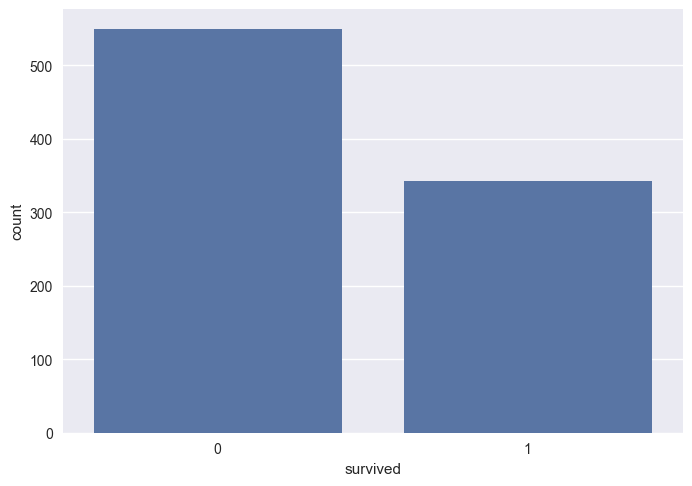

In [47]:
sns.countplot(data=df,x='survived')

##### Observation - 
##### 1. Most of the passengers of the titanic did not survive

### Bivariate Analysis

#### Does Passenger Class affect Survival?

Text(0, 0.5, 'Survival Rate')

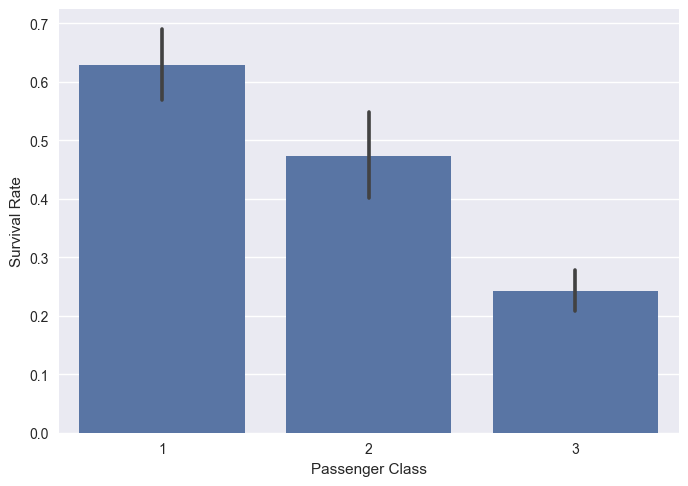

In [50]:
sns.barplot(data=df,x='pclass',y='survived')
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

##### Observation - 
##### 1. Passenger class does seem to affect the survivability of the passengers
##### 2. The Passengers in class 1 had comparatively higher survivability rate than other class
##### 3. The Passengers in class 3 had the lowest survivability rate

#### Does Gender affect Survival?

Text(0, 0.5, 'Survival Rate')

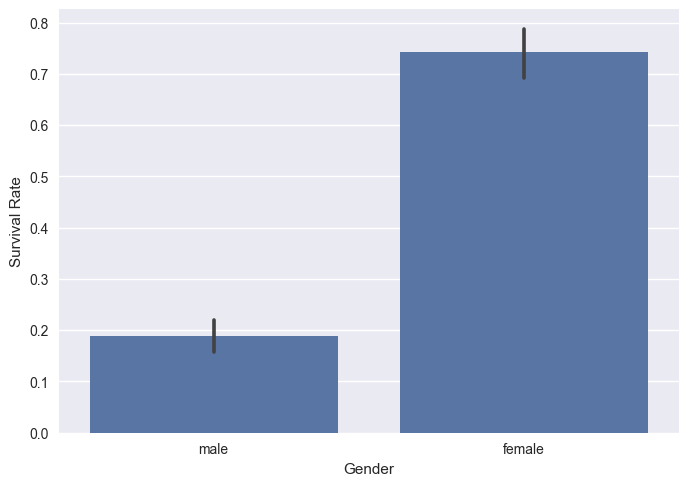

In [51]:
sns.barplot(
    data=df,
    x='sex',
    y='survived'
)
plt.xlabel("Gender")
plt.ylabel("Survival Rate")

##### Observation - 
##### 1. Gender does seem to affect the survivability of the passengers
##### 2. Female Passengers had exceptionally higher survivability rate with 75%-77% of passengers surviving
##### 3. Male passengers had very low survivability rate of 18%-19%

#### Does Age affect Survivability?

Text(0, 0.5, 'Survival Rate')

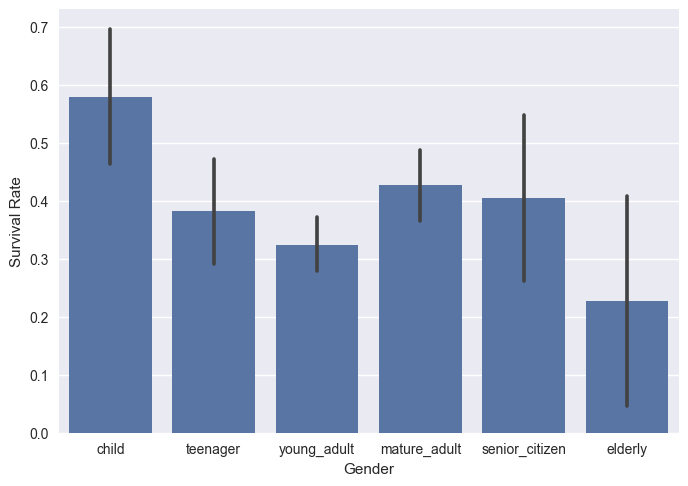

In [54]:
df['age_range'] = pd.cut(
    df['age'],
    bins=[0,12,20,30,50,60,100],
    labels=['child','teenager','young_adult','mature_adult','senior_citizen','elderly']
)
sns.barplot(
    data=df,
    x='age_range',
    y='survived'
)
plt.xlabel("Gender")
plt.ylabel("Survival Rate")

##### Observation - 
##### 1. Children under the age range of upto 12 years had higher survivability 
##### 2. ELderly people in the agr range of 60 and higher had the lowest survivability 

#### Does Fare Affect Survival??

Text(0, 0.5, 'Survival Rate')

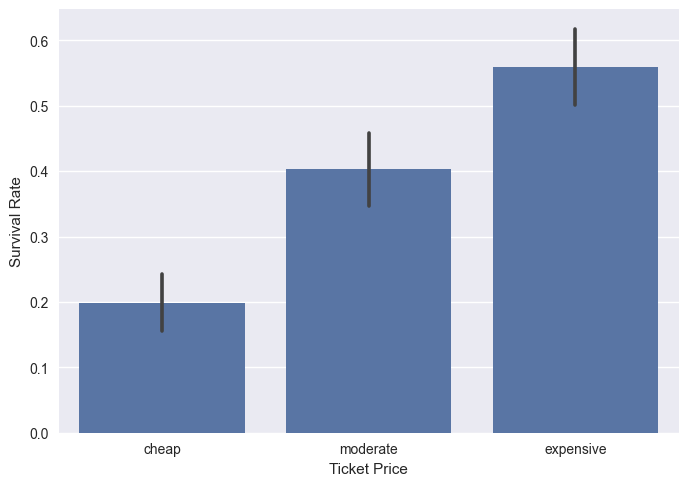

In [66]:
df['fare_range'] = pd.qcut(
    df['fare'],
    q=3,
    labels=['cheap','moderate','expensive']
)
sns.barplot(
    data=df,
    x='fare_range',
    y='survived',
)
plt.xlabel("Ticket Price")
plt.ylabel("Survival Rate")

##### Observation - 
##### 1. Fare most certainly seems to affect survivability
##### 2. Passengers who paid handsomely had higher survivability than passengers who paid less in comparison

#### Does Embarked Town affect Survival?

<Axes: xlabel='embark_town', ylabel='survived'>

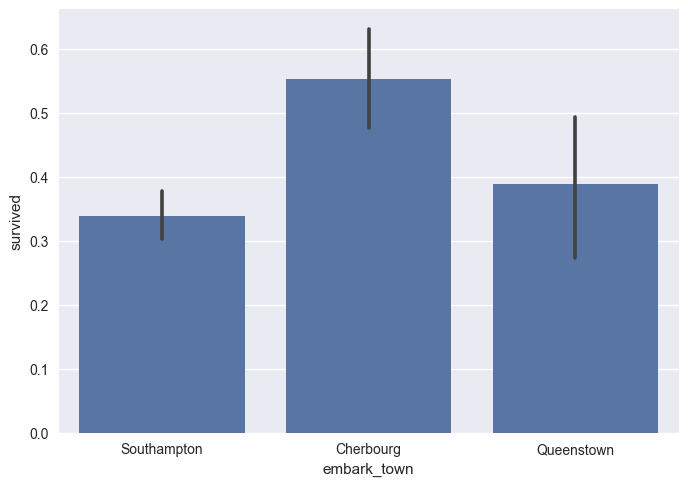

In [57]:
sns.barplot(
    data=df,
    x='embark_town',
    y='survived'
)

##### Observation - 
##### 1. Embarked Town also seems to affect survivability
##### 2. The passengers of Cherbourg had the highest Survivability

### Multivariate Analysis

#### Passenger class and Gender v/s Survivability

<Axes: xlabel='pclass', ylabel='survived'>

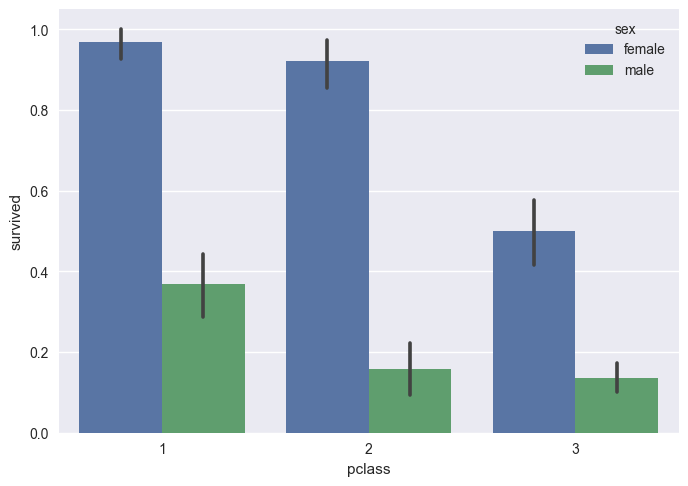

In [62]:
sns.barplot(
    data=df,
    x='pclass',
    y='survived',
    hue='sex'
)

##### Observation - 
##### 1. Passenger class and gender both in a combinely fashion affect survivability
##### 1. Females in all class had better survivability than males
##### 1. Females in passenger class 1 had the highest Survivability Rate

#### Embarked Gender v/s Survivability

<Axes: xlabel='embarked', ylabel='survived'>

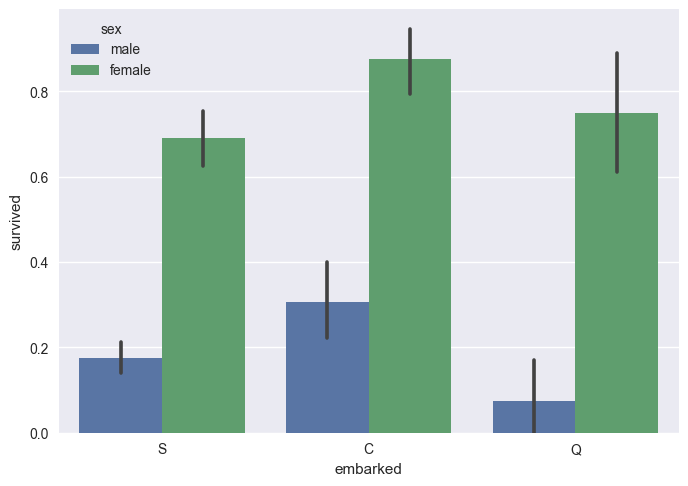

In [63]:
sns.barplot(
    data=df,
    x='embarked',
    y='survived',
    hue='sex'
)

##### Observation - 
##### 1. Embarked Town and Gender combined also seems to affect survivability
##### 2. The females passengers of Cherbourg had the highest Survivability
##### 2. The male passengers of Queenstown had the lowest Survivability

### Correlation Analysis

<Axes: >

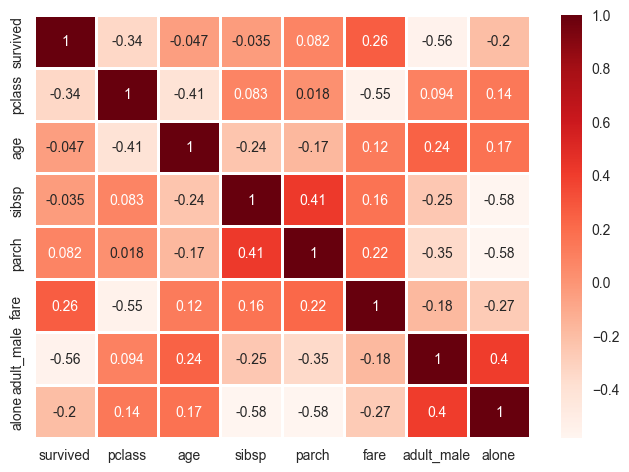

In [64]:
coer=df.corr(numeric_only=True)
sns.heatmap(coer,annot=True,cmap="Reds",linewidths=2)

##### Observation - 
##### 1. Survived is most positively correlated to fare and most negatively correlated to adult_male

## Insights

#### 1. Most of the passengers were in the age group of 20-30 years
#### 2. Most of the passengers were males
#### 3. Most of the passengers paid comparatively low for the Fare
#### 4. A larger propotion of the passengers were from Third passenger class 
#### 5. More than 50% of the passengers did not survive
#### 6. Males had the lowest survivability rate and Females had the highest survivability rate
#### 7. Passenger class also affected survivability with First class having higher survivability than second and second having more than third
#### 8. Female Passengers in all passenger class had better survivability than Male passengers in all Class
#### 9. Passengers who paid higher fare had better survivability to those who paid less